In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import math
import numpy.linalg as la
from skimage.feature import (corner_harris, corner_peaks, match_descriptors, ORB)
from skimage.transform import warp, ProjectiveTransform
from skimage.color import rgb2gray
from skimage.measure import ransac
from skimage import exposure

#CONSTANTS
Z_MAX = 256
Z_MIN = 0
L = 50  # Lambda smoothing factor

#MAIN FUNCTIONS
def load_images(img_f_names, pre_fix="", channel=-1):
    images = []
    for f_name in img_f_names:
        # Read image
        path = os.path.join(pre_fix, f_name)
        im = cv2.imread(path, 1)
        if im is None:
            print(f"Error: Could not read image {path}")
            continue

        if 0 <= channel < 3:
            images.append(im[:, :, channel])
        else:
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            images.append(im)
    return images

def get_weights(z_min, z_max):
    w = []
    for z in range(z_min, z_max):
        if z <= (z_max + z_min) * 0.5:
            w.append(z - z_min + 1)
        else:
            w.append(z_max - z + 1)
    return w

def solve_dm_response_function(Z, B, l, w):
    n = Z_MAX
    num_samples = Z.shape[1]
    num_images = Z.shape[0]

    A = np.zeros((num_samples * num_images + n + 1, n + num_samples), dtype=np.float32)
    b = np.zeros((A.shape[0]), dtype=np.float32)

    k = 0
    for i in range(num_samples):
        for j in range(num_images):
            z = int(Z[j, i])
            wij = w[z]
            A[k, z] = wij
            A[k, n + i] = -1 * wij
            b[k] = wij * B[j]
            k += 1

    A[k, 128] = 1
    k += 1

    for i in range(n - 1):
        A[k, i] = l * w[i + 1]
        A[k, i + 1] = -2 * l * w[i + 1]
        A[k, i + 2] = l * w[i + 1]
        k += 1

    x = np.linalg.lstsq(A, b, rcond=None)[0]
    g = x[:n]
    lE = x[n:]
    return g, lE

def hdr_debevec_malik(im_list, exposure_times, l=L, sample_size=30):
    B = np.log2(np.array(exposure_times))
    w = get_weights(Z_MIN, Z_MAX)
    list_len = len(im_list)
    Z = np.zeros((list_len, sample_size * sample_size))

    i = 0
    for im in im_list:
        im_resized = cv2.resize(im, (sample_size, sample_size))
        flat_im = im_resized.flatten()
        Z[i] = flat_im
        i += 1

    return solve_dm_response_function(Z, B, l, w)

def get_radiance_map(img_list, g, exposure_times):
    w = get_weights(Z_MIN, Z_MAX)
    w = np.array(w)
    log_exposure_times = np.log2(np.array(exposure_times))
    numerator = np.zeros(img_list[0].shape)
    denominator = np.zeros(img_list[0].shape)

    j = 0
    for img in img_list:
        numerator = numerator + w[img] * (g[img] - log_exposure_times[j])
        denominator = denominator + w[img]
        j += 1

    # To Avoid division by zero
    radiance_map = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    return radiance_map

def construct_HDR(imgs, response_funcs, exposures):
    shape = imgs[0][0].shape
    full_rad_map = np.zeros((shape[0], shape[1], 3))

    for i in range(3):
        radiance_map = get_radiance_map(imgs[i], response_funcs[i], exposures)
        full_rad_map[..., i] = radiance_map

    hdr = np.exp2(full_rad_map)
    return hdr

def apply_tonemap_reinhard(hdr, args=[2, 0, 0, 0]):
    hdr = np.float32(hdr)
    tonemap = cv2.createTonemapReinhard(*args)
    ldr = tonemap.process(hdr)
    ldr = np.clip(ldr * 255, 0, 255)
    return cv2.cvtColor(ldr, cv2.COLOR_BGR2RGB).astype(int), ldr.astype(int)

# --- ALIGNMENT FUNCTIONS (FIXED) ---
def histogram_eq(img):
    p2, p98 = np.percentile(img, (2, 98))
    img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
    img_adapteq = exposure.equalize_adapthist(img_rescale, clip_limit=0.03)
    return img_adapteq

def image_alignment(imL, imR, percent_kp_used=0.15, boost_con=True):
    imLgray = rgb2gray(imL)
    imRgray = rgb2gray(imR)

    if boost_con:
        imRgray = histogram_eq(imRgray)
        imLgray = histogram_eq(imLgray)

    # Detect Keypoints
    keypointsL = corner_peaks(corner_harris(imLgray), threshold_rel=0.0005, min_distance=6)
    keypointsR = corner_peaks(corner_harris(imRgray), threshold_rel=0.0005, min_distance=6)

    # Limit number of keypoints for performance
    keypointsL = keypointsL[:int(len(keypointsL) * percent_kp_used)]
    keypointsR = keypointsR[:int(len(keypointsR) * percent_kp_used)]

    # --- FIX: USE ORB INSTEAD OF BRIEF ---
    # ORB is the replacement for BRIEF in newer scikit-image versions
    extractor = ORB(n_keypoints=1000)

    # Extract features
    extractor.extract(imLgray, keypointsL)
    keypointsL = keypointsL[extractor.mask]
    descriptorsL = extractor.descriptors

    extractor.extract(imRgray, keypointsR)
    keypointsR = keypointsR[extractor.mask]
    descriptorsR = extractor.descriptors

    # Match descriptors
    matchesLR = match_descriptors(descriptorsL, descriptorsR, cross_check=True)

    if len(matchesLR) == 0:
        print("Warning: No matches found between images.")
        return imR # Return original if alignment fails

    matchL = keypointsL[matchesLR[:, 0]]
    matchR = keypointsR[matchesLR[:, 1]]

    # Estimate homography
    model_transform, inliers = ransac(
        (np.flip(matchR, axis=1), np.flip(matchL, axis=1)),
        ProjectiveTransform, min_samples=4, residual_threshold=2, max_trials=100
    )

    # Apply warp
    if model_transform is None:
        return imR

    projectedR = warp(imR, model_transform.inverse, output_shape=(imL.shape[0], imL.shape[1]))
    return projectedR

def get_all_img_aligned(images, percent_kp_used=0.15, boost_con=True):
    base_img = images[0]
    aligned_imgs = [base_img]
    print("Aligning images...")
    for i in range(1, len(images)):
        try:
            im_align = image_alignment(base_img, images[i], percent_kp_used=percent_kp_used, boost_con=boost_con)
            aligned_imgs.append(im_align * 255)
            print(f"Aligned image {i+1}/{len(images)}")
        except Exception as e:
            print(f"Alignment failed for image {i+1}: {e}. Using original.")
            aligned_imgs.append(images[i])
    return aligned_imgs

def get_channel_list(imgs, channel):
    channel_list = []
    for img in imgs:
        channel_list.append(np.array(img[:, :, channel], dtype="uint8"))
    return channel_list

print("Functions loaded successfully.")

Functions loaded successfully.


1. Loading images...
Aligning images...
Alignment failed for image 2: ORB.extract() missing 2 required positional arguments: 'scales' and 'orientations'. Using original.
Alignment failed for image 3: ORB.extract() missing 2 required positional arguments: 'scales' and 'orientations'. Using original.
Estimating response functions...
Constructing HDR map...
Applying tone mapping...
Success! Image saved to final_results/result_hdr.jpg


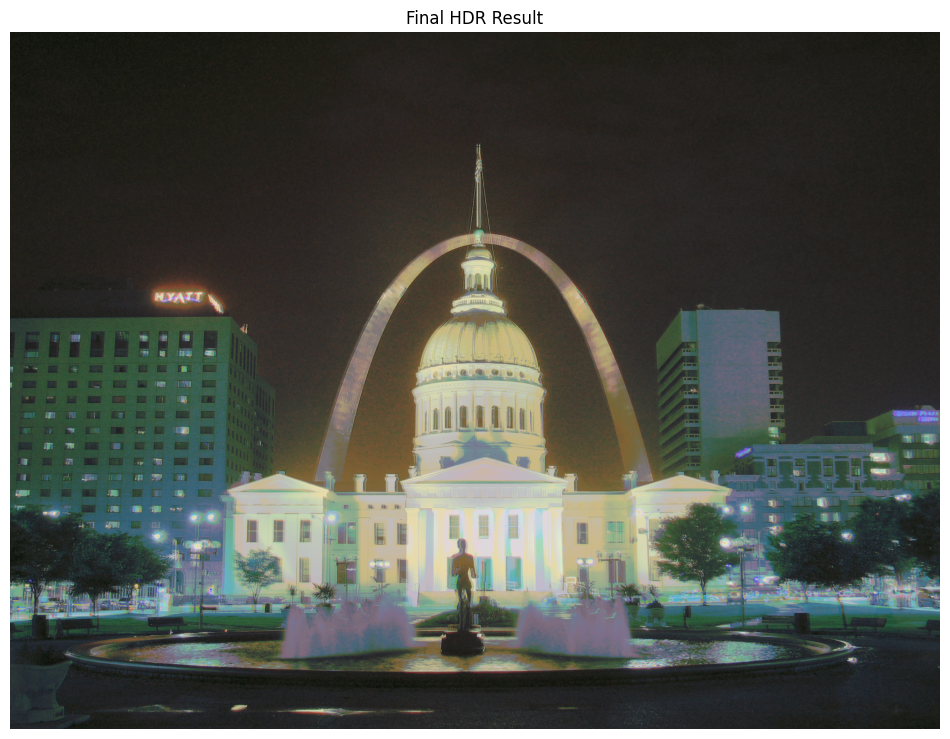

In [ ]:
# MAIN EXECUTION:
f_names = ["1.jpg", "2.jpg", "3.jpg"]

# Shutter speeds (exposure times) in seconds for each image
exposures = [0.033, 0.25, 2.5]
try:
    print("1. Loading images...")
    # Load images from the 'images' folder
    images = load_images(f_names, "images/")

    if len(images) != len(f_names):
        print("Error: Could not load all images. Please check filenames and upload again.")
    else:
        # 2. Align Images
        # (percent_kp_used=0.4 uses 40% of keypoints for better accuracy)
        aligned_imgs = get_all_img_aligned(images, percent_kp_used=0.8, boost_con=False)

        # 3. Separate Channels (BGR format)
        im_b = get_channel_list(aligned_imgs, 0)
        im_g = get_channel_list(aligned_imgs, 1)
        im_r = get_channel_list(aligned_imgs, 2)

        # 4. Estimate Response Functions (Debevec-Malik)
        print("Estimating response functions...")
        gb, _ = hdr_debevec_malik(im_b, exposures)
        gg, _ = hdr_debevec_malik(im_g, exposures)
        gr, _ = hdr_debevec_malik(im_r, exposures)

        # 5. Construct HDR Radiance Map
        print("Constructing HDR map...")
        hdr = construct_HDR([im_b, im_g, im_r], [gb, gg, gr], exposures)

        # 6. Tone Mapping (Reinhard)
        print("Applying tone mapping...")
        # Parameters: [gamma, contrast, saturation, detail]
        ldr_im, ldr_im_bgr = apply_tonemap_reinhard(hdr, [1.5, 0.5, 0.5, 0.5])

        # 7. Save and Display
        save_path = "final_results/result_hdr.jpg"
        cv2.imwrite(save_path, ldr_im_bgr)
        print(f"Success! Image saved to {save_path}")

        plt.figure(figsize=(12, 12))
        plt.title("Final HDR Result")
        plt.imshow(ldr_im.astype(int))
        plt.axis('off')
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")